In [35]:
import numpy as np
import matplotlib.pyplot as plt
import os
import mido
from lookup_delta_3d import *
from mm_part_to_part import *
import IPython.display as ipd
from midi_helpers import *

In [36]:
#get the lookup table
#copied this from the delta_3d_lookup.py file

train_dir = os.path.join('jsb_chorales', 'train')
lookup_table_bass = get_delta_3d_lookup(train_dir)
lookup_table_tenor = get_delta_3d_lookup(train_dir, part='tenor')
lookup_table_alto = get_delta_3d_lookup(train_dir, part='alto')

alto_to_alto_transition, tenor_to_tenor_transition, bass_to_bass_transition = train_part_to_part_markov(train_dir)

Parsing CSVs: 100%|██████████| 229/229 [00:00<00:00, 1896.42song/s]


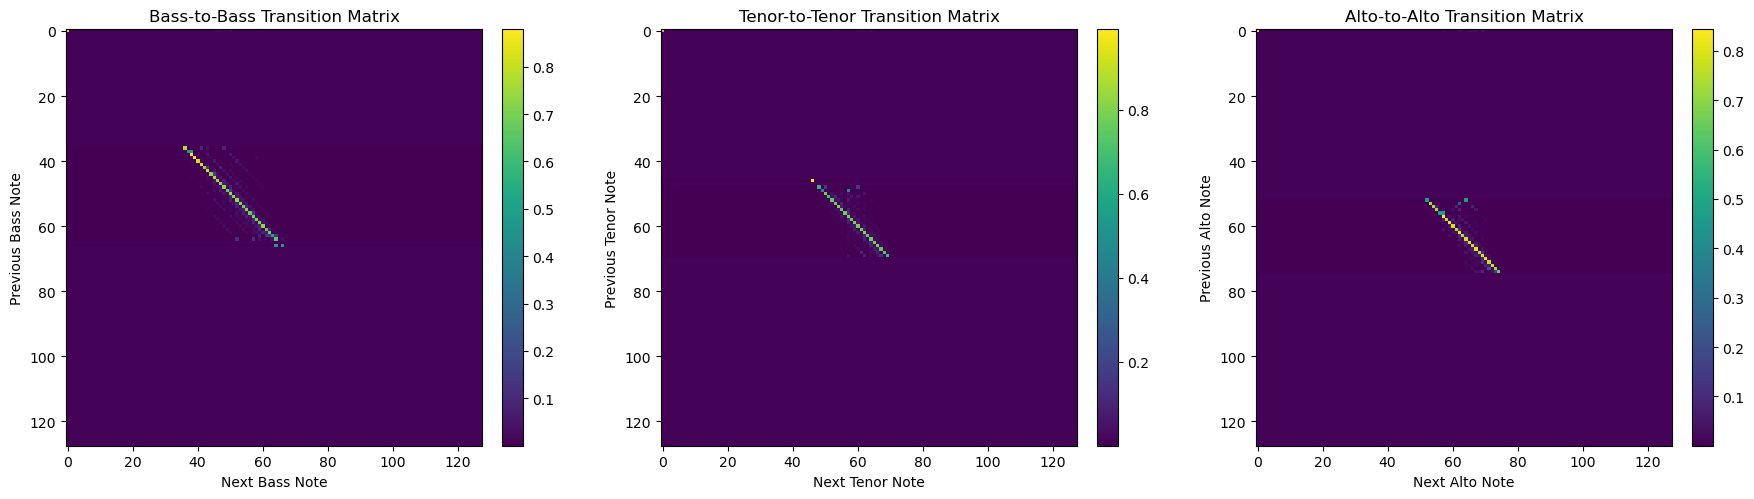

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

im0 = axs[0].imshow(bass_to_bass_transition)
axs[0].set_title("Bass-to-Bass Transition Matrix")
axs[0].set_xlabel("Next Bass Note")
axs[0].set_ylabel("Previous Bass Note")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(tenor_to_tenor_transition)
axs[1].set_title("Tenor-to-Tenor Transition Matrix")
axs[1].set_xlabel("Next Tenor Note")
axs[1].set_ylabel("Previous Tenor Note")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

im2 = axs[2].imshow(alto_to_alto_transition)
axs[2].set_title("Alto-to-Alto Transition Matrix")
axs[2].set_xlabel("Next Alto Note")
axs[2].set_ylabel("Previous Alto Note")
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [38]:
def get_part_line(lookup_table, A, soprano_input, l=1):
    """
    Inputs
      - lookup_table: a matrix containing log probabilities P(delta | soprano_{n-1}, part_n) of size (128, 128, 2*num_semitones+2), indexed (part, prev_soprano, delta)
      - A: an 128 x 128 matrix specifying transitions of part's notes between moments in time
      - soprano input -- a 1d array of soprano midi notes
        
    Outputs
      - part_est: the supporting part line
    """
    ### INSERT CODE BELOW ###
    
    #grab dimensions and initialize cumulative cost matrix
    N = np.size(soprano_input)
    M = 128

    #make sure A and pi has no zeros
    A = np.clip(A, 1E-9, 1) # we don't even have to renormalize?

    D = np.zeros((M, N))
    B = np.zeros((M, N))

    #initialize probabilities
    D[:, 0] = np.sum(lookup_table[:, :, :], axis=(1,2)) #should add log(P(O_1 | S_1)) term
    #just writes total probability of being in that bass note (sums over soprano and delta dimensions)

    #lookup table is indexed (bass, prev_soprano, delta)
    #walk through the matrix
    for j in range(1, N):
      delta = soprano_input[j] - soprano_input[j-1]
      for i in range(M):
        D[i, j] = np.max(D[:, j-1] + np.log(A[:, i])+ l*lookup_table[:, int(soprano_input[j-1]), delta_2_index(delta)])
        B[i,j] = np.argmax(D[:, j-1] + np.log(A[:, i])+ l*lookup_table[:, int(soprano_input[j-1]), delta_2_index(delta)])

        #best_index = int(B[i,j])
        #print(np.log(A[best_index, i]), l*lookup_table[best_index, int(soprano_input[j-1]), delta_2_index(delta)])
  

    part_est = np.zeros(N, dtype = int)
    endpoint = np.argmax(D[:, -1])
    part_est[-1] = endpoint

    for i in range(N-1)[::-1]:
      part_est[i] = B[int(part_est[i+1]), i+1]

    return part_est

In [42]:
path = os.path.join('jsb_chorales', 'test', 'chorale_312.csv')
S, _, _, _ = csv_to_tracks(path)

B = get_part_line(lookup_table_bass, bass_to_bass_transition, S, l=1)
A = get_part_line(lookup_table_alto, alto_to_alto_transition, S, l=1)
T = get_part_line(lookup_table_tenor, tenor_to_tenor_transition, S, l=1)

In [43]:
arrays_to_midi((S, A, T, B))

Successfully saved to output.mid


In [44]:
midi_arrays_to_ipd((S, A, T, B), bpm=120, save_wav=True, wav_filename="output.wav")